# Facial Landmark Detection — YOLO11 (5 pts) + FaceMesh (478 pts)

Two landmark detectors demonstrated on an easy and a hard image.

| Model | Keypoints | Notes |
|---|---|---|
| `YoloFace11Detector` | 5 pts | right eye · left eye · nose · mouth-right · mouth-left |
| `FaceMeshWrapper` | 478 pts | MediaPipe dense facial mesh; requires a face crop as input |

**Workflow:**
1. `YoloFace11Detector` detects faces and provides 5-point keypoints directly.
2. `FaceMeshWrapper` runs on the face crop from `det.crop(square=True)` and returns 478 landmarks.
3. `visualize_detection(det)` and `visualize_detection_crop(det)` draw YOLO11 keypoints.
4. `visualize_landmarks(crop, lmks)` draws FaceMesh landmarks on the crop.

/Users/fodorad/miniconda3/envs/exordium/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


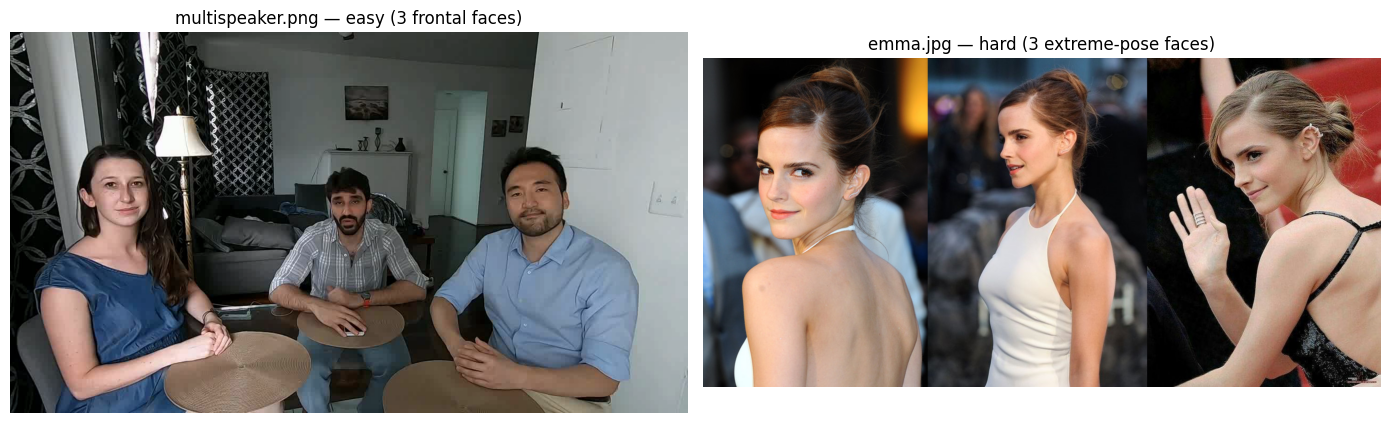

In [1]:
import matplotlib.pyplot as plt

from exordium import FIXTURE_DIR
from exordium.video.core.io import image_to_np

multispeaker_path = FIXTURE_DIR / "image" / "multispeaker.png"  # easy: 3 frontal faces
emma_path = FIXTURE_DIR / "image" / "emma.jpg"  # hard: 3 extreme-pose faces

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image_to_np(multispeaker_path))
axes[0].set_title("multispeaker.png — easy (3 frontal faces)")
axes[0].axis("off")
axes[1].imshow(image_to_np(emma_path))
axes[1].set_title("emma.jpg — hard (3 extreme-pose faces)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Load models

In [2]:
from exordium.video.face.detector.yolo11 import YoloFace11Detector
from exordium.video.face.landmark.facemesh import FaceMeshWrapper

detector = YoloFace11Detector(device_id=None, conf=0.7)
facemesh = FaceMeshWrapper(min_detection_confidence=0.5)

2026-03-22 13:40:33 INFO YoloFace11Detector loaded 'yolo11n-pose_widerface' on cpu (conf=0.7).
W0000 00:00:1774183233.967540 2442254 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1774183234.018383 2442254 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774183234.019319 2442256 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774183234.023876 2442264 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
2026-03-22 13:40:34 INFO MediaPipe FaceMesh loaded.


---
## Easy image — `multispeaker.png` (3 frontal faces)

In [3]:
ms_dets = detector.detect_image_path(multispeaker_path)

print(f"YOLO11 — {len(ms_dets)} face(s) detected")
for i, det in enumerate(ms_dets):
    print(f"  face {i}  score={det.score:.3f}  bb={[int(v) for v in det.bb_xyxy]}")
    print(f"           landmarks (5×2): {det.landmarks.tolist()}")

YOLO11 — 3 face(s) detected
  face 0  score=0.853  bb=[936, 246, 1041, 382]
           landmarks (5×2): [[957, 308], [1003, 301], [979, 325], [967, 350], [1006, 344]]
  face 1  score=0.847  bb=[156, 236, 261, 365]
           landmarks (5×2): [[193, 294], [241, 288], [224, 317], [201, 335], [241, 330]]
  face 2  score=0.813  bb=[605, 291, 672, 381]
           landmarks (5×2): [[621, 324], [652, 322], [635, 342], [626, 358], [651, 356]]


### YOLO11 — 5-point keypoints

`visualize_detection_crop(det)` crops the face, projects the keypoints into crop
coordinates, and draws them — all in one call.

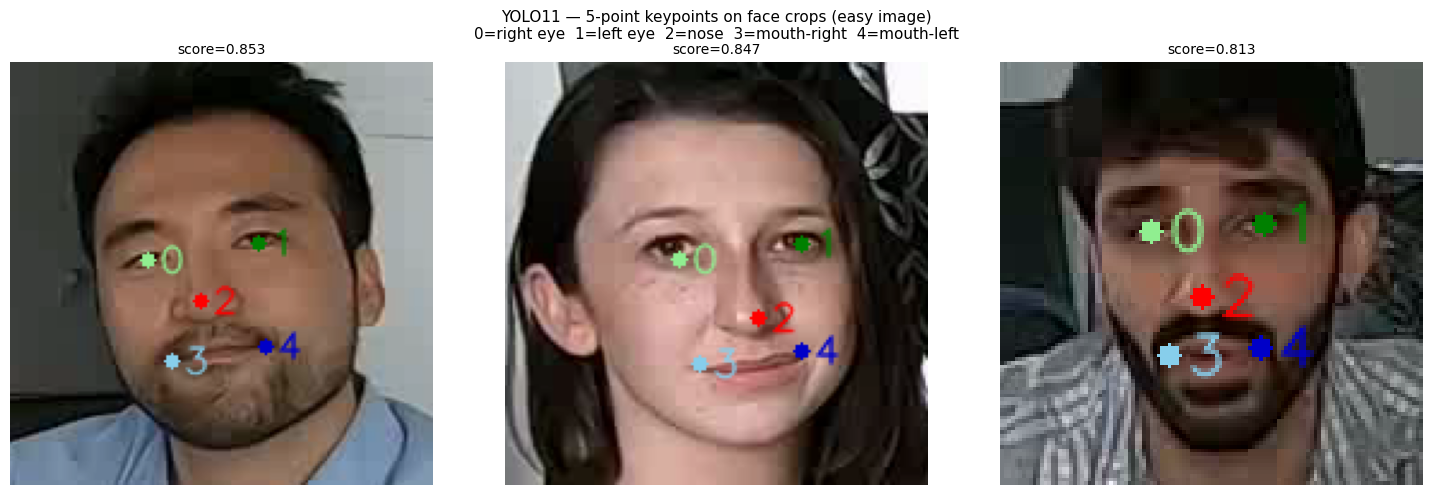

In [4]:
from exordium.video.core.detection import visualize_detection_crop

n = len(ms_dets)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]
for ax, det in zip(axes, ms_dets):
    # One liner: crop + project landmarks + draw numbered keypoints
    ax.imshow(visualize_detection_crop(det, square=True, extra_space=1.3, show_indices=True))
    ax.set_title(f"score={det.score:.3f}", fontsize=10)
    ax.axis("off")
plt.suptitle(
    "YOLO11 — 5-point keypoints on face crops (easy image)\n"
    "0=right eye  1=left eye  2=nose  3=mouth-right  4=mouth-left",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### FaceMesh — 478-point dense landmarks

`FaceMeshWrapper([crop_numpy])` takes a list of face crops as `(H, W, 3)` RGB
numpy arrays and returns a list of `(478, 2)` landmark tensors in crop-local
pixel coordinates.

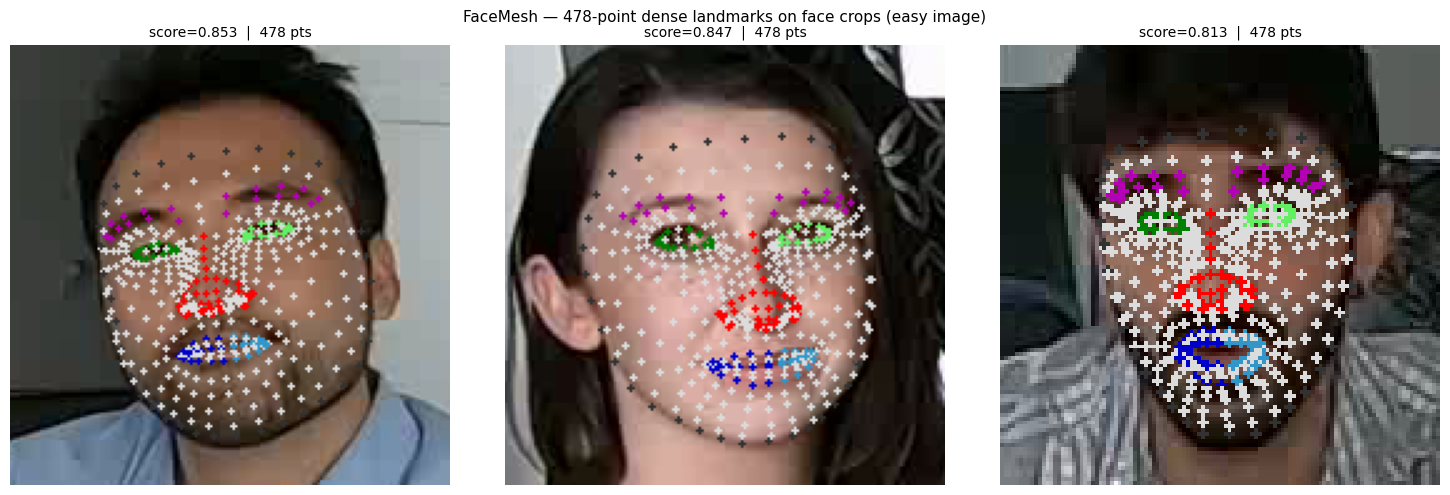

In [5]:
from exordium.video.face.landmark.constants import FACEMESH_REGION_COLORS
from exordium.video.face.landmark.facemesh import visualize_landmarks

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for ax, det in zip(axes, ms_dets):
    # crop() → (3, H', W') uint8 tensor; convert to (H', W', 3) numpy for FaceMesh
    crop = det.crop(square=True, extra_space=1.3)  # (3, H', W') RGB tensor

    lmks_list = facemesh([crop])  # list of (478, 2) tensors
    if lmks_list:
        vis = visualize_landmarks(
            crop, lmks_list[0], radius=1, colors=FACEMESH_REGION_COLORS, show_indices=False
        )
        ax.imshow(vis)
        ax.set_title(f"score={det.score:.3f}  |  478 pts", fontsize=10)
    else:
        ax.imshow(crop.permute(1, 2, 0).numpy())
        ax.set_title(f"score={det.score:.3f}  |  no mesh", fontsize=10)
    ax.axis("off")

plt.suptitle("FaceMesh — 478-point dense landmarks on face crops (easy image)", fontsize=11)
plt.tight_layout()
plt.show()

---
## Hard image — `emma.jpg` (3 extreme-pose faces)

Large yaw / pitch / roll angles.  YOLO11 still detects all 3 faces.
FaceMesh accuracy degrades on strongly non-frontal crops — this is a model
limitation, not a code issue.

In [6]:
em_dets = detector.detect_image_path(emma_path)

print(f"YOLO11 — {len(em_dets)} face(s) detected")
for i, det in enumerate(em_dets):
    print(f"  face {i}  score={det.score:.3f}  bb={[int(v) for v in det.bb_xyxy]}")

YOLO11 — 3 face(s) detected
  face 0  score=0.856  bb=[312, 383, 809, 1035]
  face 1  score=0.825  bb=[1698, 254, 2033, 747]
  face 2  score=0.798  bb=[2978, 341, 3440, 900]


### YOLO11 — 5-point keypoints (hard image)

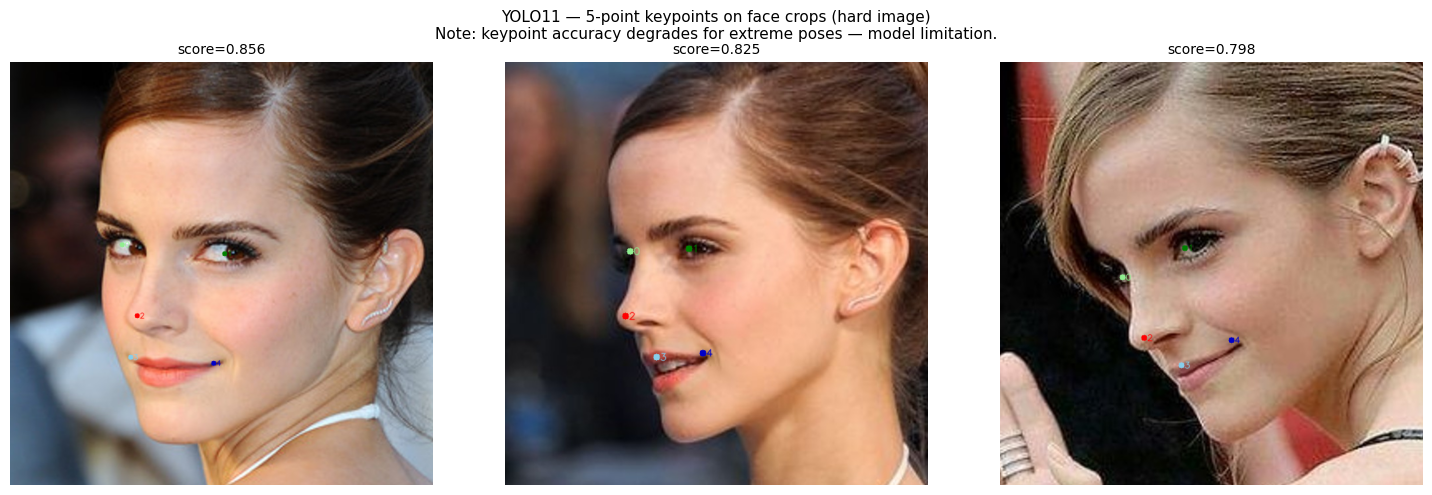

In [7]:
n_em = len(em_dets)
fig, axes = plt.subplots(1, n_em, figsize=(5 * n_em, 5))
if n_em == 1:
    axes = [axes]
for ax, det in zip(axes, em_dets):
    ax.imshow(
        visualize_detection_crop(det, square=True, extra_space=1.3, radius=5, show_indices=True)
    )
    ax.set_title(f"score={det.score:.3f}", fontsize=10)
    ax.axis("off")
plt.suptitle(
    "YOLO11 — 5-point keypoints on face crops (hard image)\n"
    "Note: keypoint accuracy degrades for extreme poses — model limitation.",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### FaceMesh — 478-point dense landmarks (hard image)

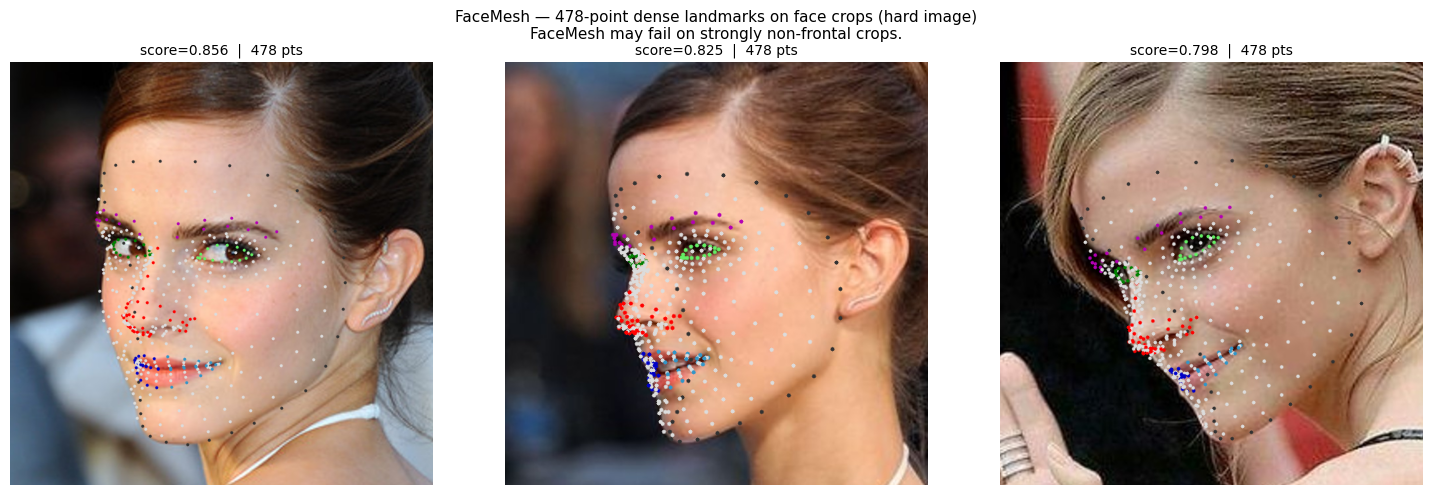

In [8]:
fig, axes = plt.subplots(1, n_em, figsize=(5 * n_em, 5))
if n_em == 1:
    axes = [axes]

for ax, det in zip(axes, em_dets):
    crop = det.crop(square=True, extra_space=1.3)

    lmks_list = facemesh([crop])
    if lmks_list:
        vis = visualize_landmarks(
            crop, lmks_list[0], radius=3, colors=FACEMESH_REGION_COLORS, show_indices=False
        )
        ax.imshow(vis)
        ax.set_title(f"score={det.score:.3f}  |  478 pts", fontsize=10)
    else:
        ax.imshow(crop.permute(1, 2, 0).numpy())
        ax.set_title(f"score={det.score:.3f}  |  no mesh detected", fontsize=10)
    ax.axis("off")

plt.suptitle(
    "FaceMesh — 478-point dense landmarks on face crops (hard image)\n"
    "FaceMesh may fail on strongly non-frontal crops.",
    fontsize=11,
)
plt.tight_layout()
plt.show()